# **SVM modeling with Engineered Features**

### **Import Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import joblib

### **Load Processed Data**

In [2]:
X_engineered_train_scaled = np.load(
    '../data/processed/X_train_scaled.npy'
)

X_engineered_test_scaled = np.load(
    '../data/processed/X_test_scaled.npy'
)

y_train = np.load(
    '../data/processed/y_train.npy'
)

y_test = np.load(
    '../data/processed/y_test.npy'
)

## **Initialize Engineered-Featured SVM**

In [3]:
engineered_svm = SVC(
    kernel='rbf',
    random_state=42
)

## **Training The Model**

In [4]:
engineered_svm.fit(X_engineered_train_scaled, y_train)  

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## **Make Predictions**

In [5]:
y_pred_engineered = engineered_svm.predict(X_engineered_test_scaled)

## **Evaluation Metrics**

### **Accuracy Score**

In [6]:
engineered_accuracy = accuracy_score(
    y_test,
    y_pred_engineered
)

print(
    f'Engineered SVM Accuracy: '
    f'{engineered_accuracy:.4f}'
)

Engineered SVM Accuracy: 0.8152


### **Classification Report**

In [7]:
print(
    classification_report(
        y_test,
        y_pred_engineered
    )
)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.67      0.32      0.43      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.66      6000
weighted avg       0.80      0.82      0.79      6000



### **Confusion Matrix**

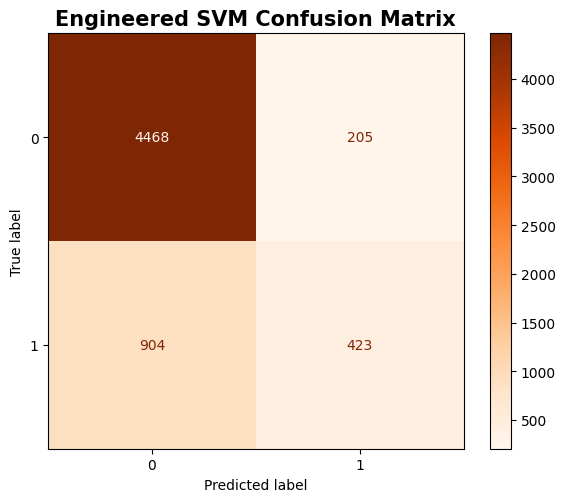

In [8]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_engineered,
    cmap='Oranges',
    ax=ax
)

plt.title(
    'Engineered SVM Confusion Matrix',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

### **ROC-AUC Score**

In [9]:
baseline_auc = roc_auc_score(
    y_test,
    y_pred_engineered
)

print(
    f'Baseline ROC-AUC Score: '
    f'{baseline_auc:.4f}'
)

Baseline ROC-AUC Score: 0.6374


## **Save Trained Model**

In [10]:
joblib.dump(
     engineered_svm,
     '../artifacts/svm_engineered.pkl'
)

['../artifacts/svm_engineered.pkl']